# Gradient Descent & Stochastic Gradient Descent from Scratch

This notebook generates a random regression dataset with **scikit-learn** and implements gradient descent manually. It visualizes the dataset, the regression line during training, loss convergence, parameter updates, and the effect of stochastic updates.


## 1. Imports and setup

We use NumPy for calculations, Matplotlib for graphs, and scikit-learn only to generate the synthetic dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True


## 2. Generate random data

The target follows approximately `y = w*x + b + noise`. The model we train will be `ŷ = w*x + b`.

In [2]:
X, y = make_regression(
    n_samples=120,
    n_features=1,
    n_informative=1,
    noise=15,
    bias=20,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training samples:', len(X_train))
print('Test samples:', len(X_test))
print('True generated relationship is approximately linear.')


Training samples: 96
Test samples: 24
True generated relationship is approximately linear.


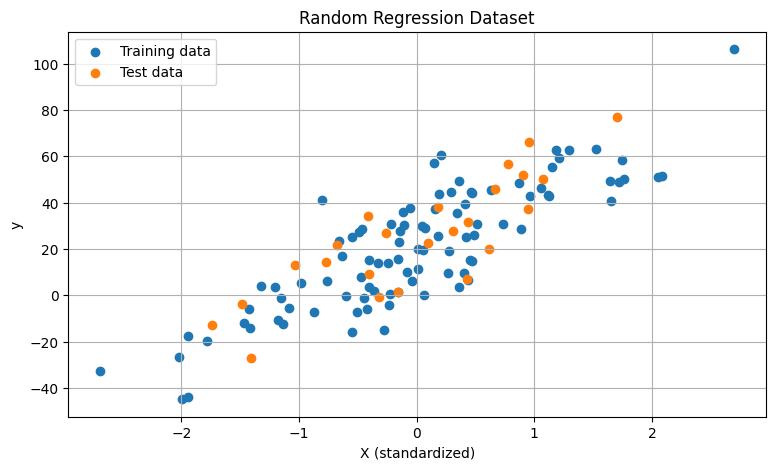

In [3]:
plt.scatter(X_train_scaled[:, 0], y_train, label='Training data')
plt.scatter(X_test_scaled[:, 0], y_test, label='Test data')
plt.xlabel('X (standardized)')
plt.ylabel('y')
plt.title('Random Regression Dataset')
plt.legend()
plt.show()


## 3. Gradient descent mathematics

For one feature:

`ŷ = w*x + b`

We use mean squared error (MSE):

`MSE = (1/n) Σ(ŷ - y)²`

The parameters are updated using:

`w = w - learning_rate * dw`

`b = b - learning_rate * db`

## 4. Batch Gradient Descent from scratch

Every epoch uses the complete training dataset to calculate the gradient.

In [4]:
def batch_gradient_descent(X, y, learning_rate=0.05, epochs=100):
    w = 0.0
    b = 0.0
    n = len(X)
    losses = []
    weight_history = []
    bias_history = []

    for epoch in range(epochs):
        predictions = w * X[:, 0] + b
        errors = predictions - y

        loss = np.mean(errors ** 2)
        dw = (2 / n) * np.sum(X[:, 0] * errors)
        db = (2 / n) * np.sum(errors)

        w -= learning_rate * dw
        b -= learning_rate * db

        losses.append(loss)
        weight_history.append(w)
        bias_history.append(b)

    return w, b, losses, weight_history, bias_history

w_gd, b_gd, gd_losses, gd_w_history, gd_b_history = batch_gradient_descent(
    X_train_scaled, y_train, learning_rate=0.05, epochs=100
)

print(f'Final weight: {w_gd:.4f}')
print(f'Final bias:   {b_gd:.4f}')


Final weight: 22.4243
Final bias:   20.7889


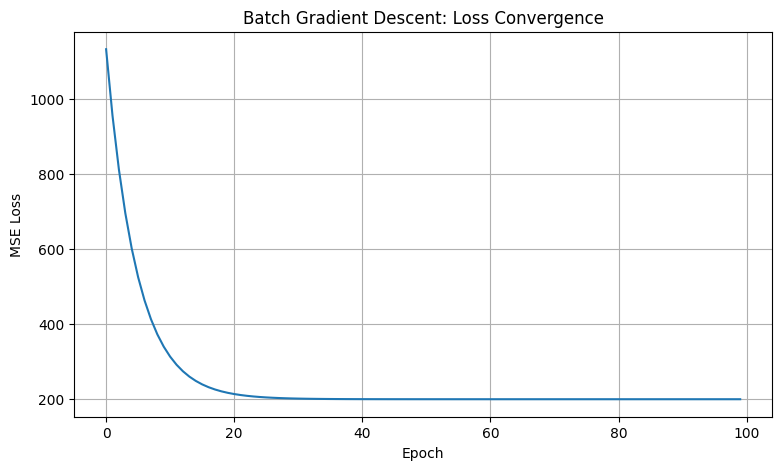

In [5]:
plt.plot(gd_losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Batch Gradient Descent: Loss Convergence')
plt.show()


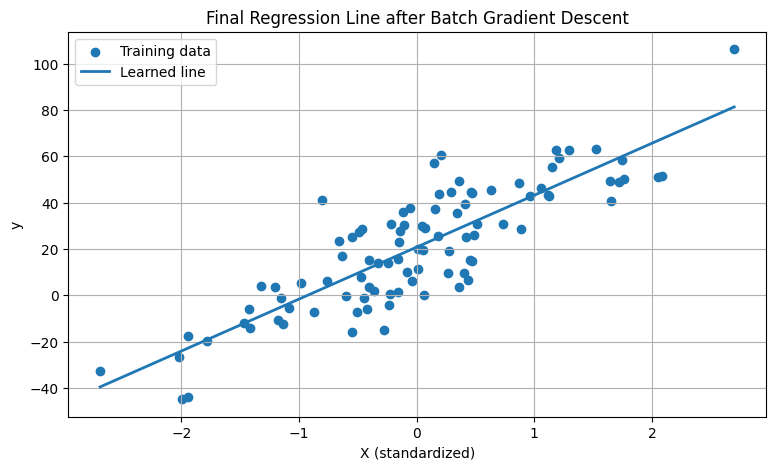

In [6]:
plt.scatter(X_train_scaled[:, 0], y_train, label='Training data')
x_line = np.linspace(X_train_scaled.min(), X_train_scaled.max(), 100)
y_line = w_gd * x_line + b_gd
plt.plot(x_line, y_line, linewidth=2, label='Learned line')
plt.xlabel('X (standardized)')
plt.ylabel('y')
plt.title('Final Regression Line after Batch Gradient Descent')
plt.legend()
plt.show()


## 5. Visualize parameter updates

The plots below show how the weight and bias move toward their final values.

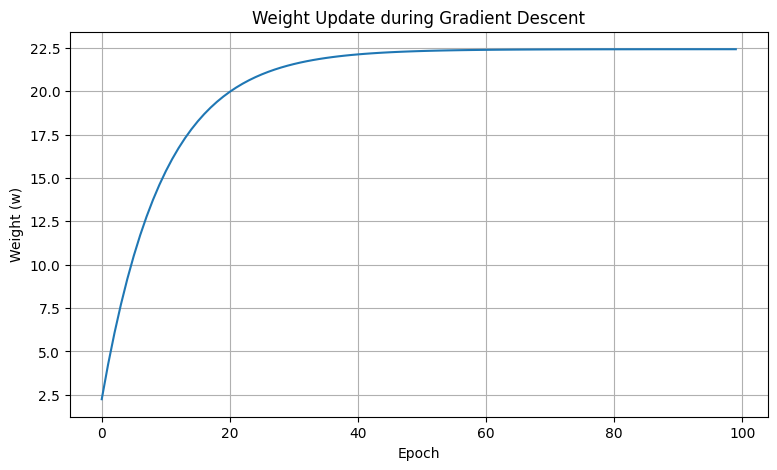

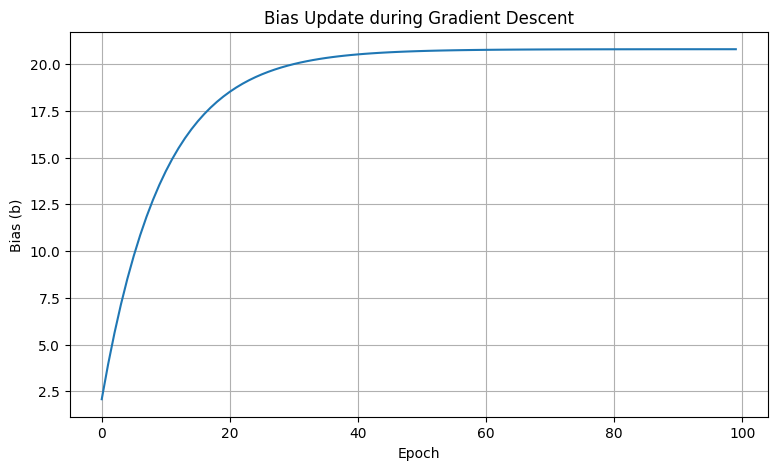

In [7]:
plt.plot(gd_w_history)
plt.xlabel('Epoch')
plt.ylabel('Weight (w)')
plt.title('Weight Update during Gradient Descent')
plt.show()

plt.plot(gd_b_history)
plt.xlabel('Epoch')
plt.ylabel('Bias (b)')
plt.title('Bias Update during Gradient Descent')
plt.show()


## 6. Stochastic Gradient Descent (SGD) from scratch

Unlike batch gradient descent, SGD updates the parameters **after every single training example**. This makes the updates noisy but often allows faster progress per update.

In [8]:
def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=30):
    w = 0.0
    b = 0.0
    losses = []
    weight_history = []
    bias_history = []
    update_losses = []

    for epoch in range(epochs):
        indices = np.random.permutation(len(X))
        epoch_losses = []

        for i in indices:
            x_i = X[i, 0]
            y_i = y[i]

            prediction = w * x_i + b
            error = prediction - y_i

            dw = 2 * x_i * error
            db = 2 * error

            w -= learning_rate * dw
            b -= learning_rate * db

            sample_loss = error ** 2
            epoch_losses.append(sample_loss)
            update_losses.append(sample_loss)
            weight_history.append(w)
            bias_history.append(b)

        # Full-dataset loss at the end of each epoch
        predictions = w * X[:, 0] + b
        losses.append(np.mean((predictions - y) ** 2))

    return w, b, losses, weight_history, bias_history, update_losses

w_sgd, b_sgd, sgd_losses, sgd_w_history, sgd_b_history, sgd_update_losses = stochastic_gradient_descent(
    X_train_scaled, y_train, learning_rate=0.01, epochs=30
)

print(f'Final SGD weight: {w_sgd:.4f}')
print(f'Final SGD bias:   {b_sgd:.4f}')


Final SGD weight: 22.7001
Final SGD bias:   19.5586


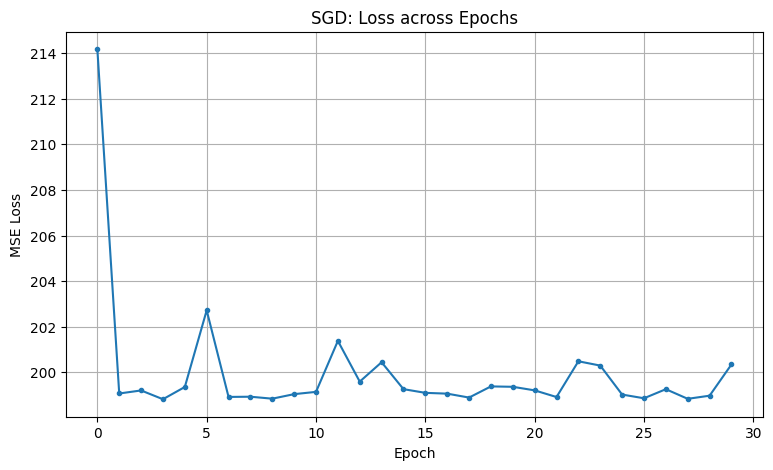

In [9]:
plt.plot(sgd_losses, marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('SGD: Loss across Epochs')
plt.show()


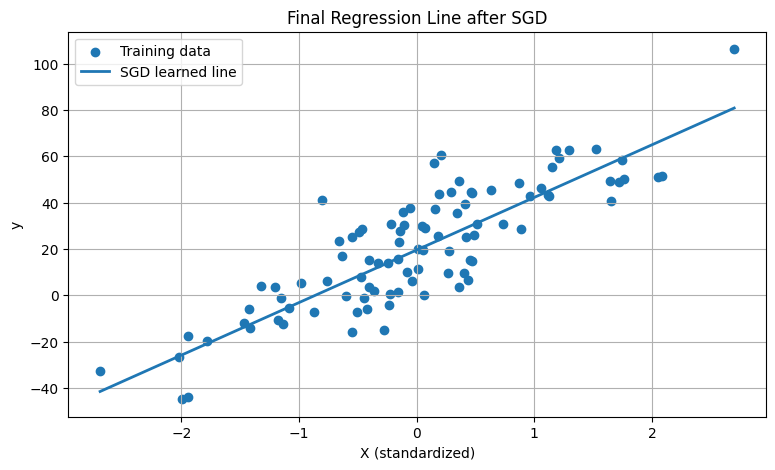

In [10]:
plt.scatter(X_train_scaled[:, 0], y_train, label='Training data')
y_sgd_line = w_sgd * x_line + b_sgd
plt.plot(x_line, y_sgd_line, linewidth=2, label='SGD learned line')
plt.xlabel('X (standardized)')
plt.ylabel('y')
plt.title('Final Regression Line after SGD')
plt.legend()
plt.show()


## 7. Visualize the noisy SGD updates

Because SGD updates once per sample, the parameter path contains many more and noisier movements than batch gradient descent.

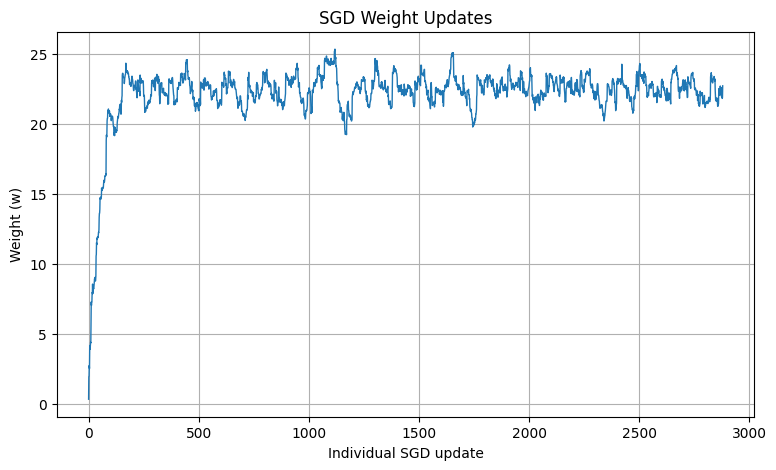

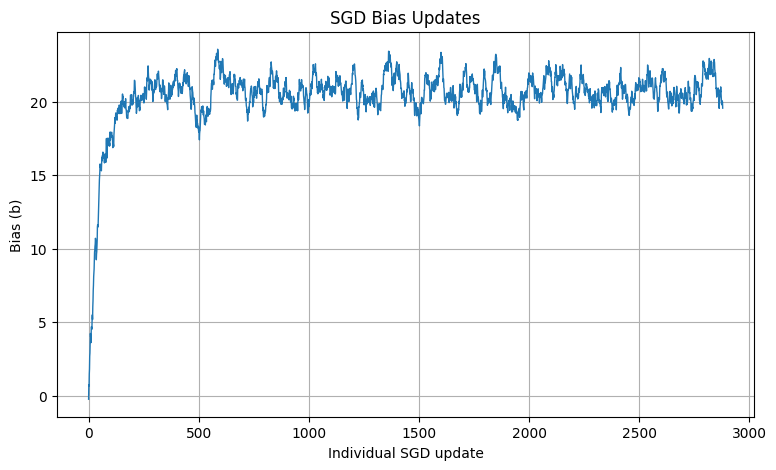

In [11]:
plt.plot(sgd_w_history, linewidth=1)
plt.xlabel('Individual SGD update')
plt.ylabel('Weight (w)')
plt.title('SGD Weight Updates')
plt.show()

plt.plot(sgd_b_history, linewidth=1)
plt.xlabel('Individual SGD update')
plt.ylabel('Bias (b)')
plt.title('SGD Bias Updates')
plt.show()


## 8. Compare Gradient Descent and SGD


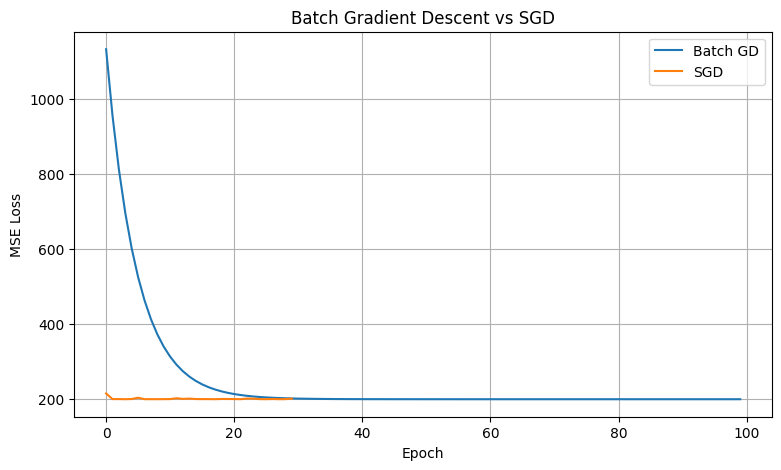

Batch GD final loss: 198.75122063270535
SGD final loss:      200.3419029636876


In [12]:
plt.plot(gd_losses, label='Batch GD')
plt.plot(sgd_losses, label='SGD')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Batch Gradient Descent vs SGD')
plt.legend()
plt.show()

print('Batch GD final loss:', gd_losses[-1])
print('SGD final loss:     ', sgd_losses[-1])


## 9. Visualize how the regression line learns

This animation-style plot shows selected training stages from the batch gradient descent history.

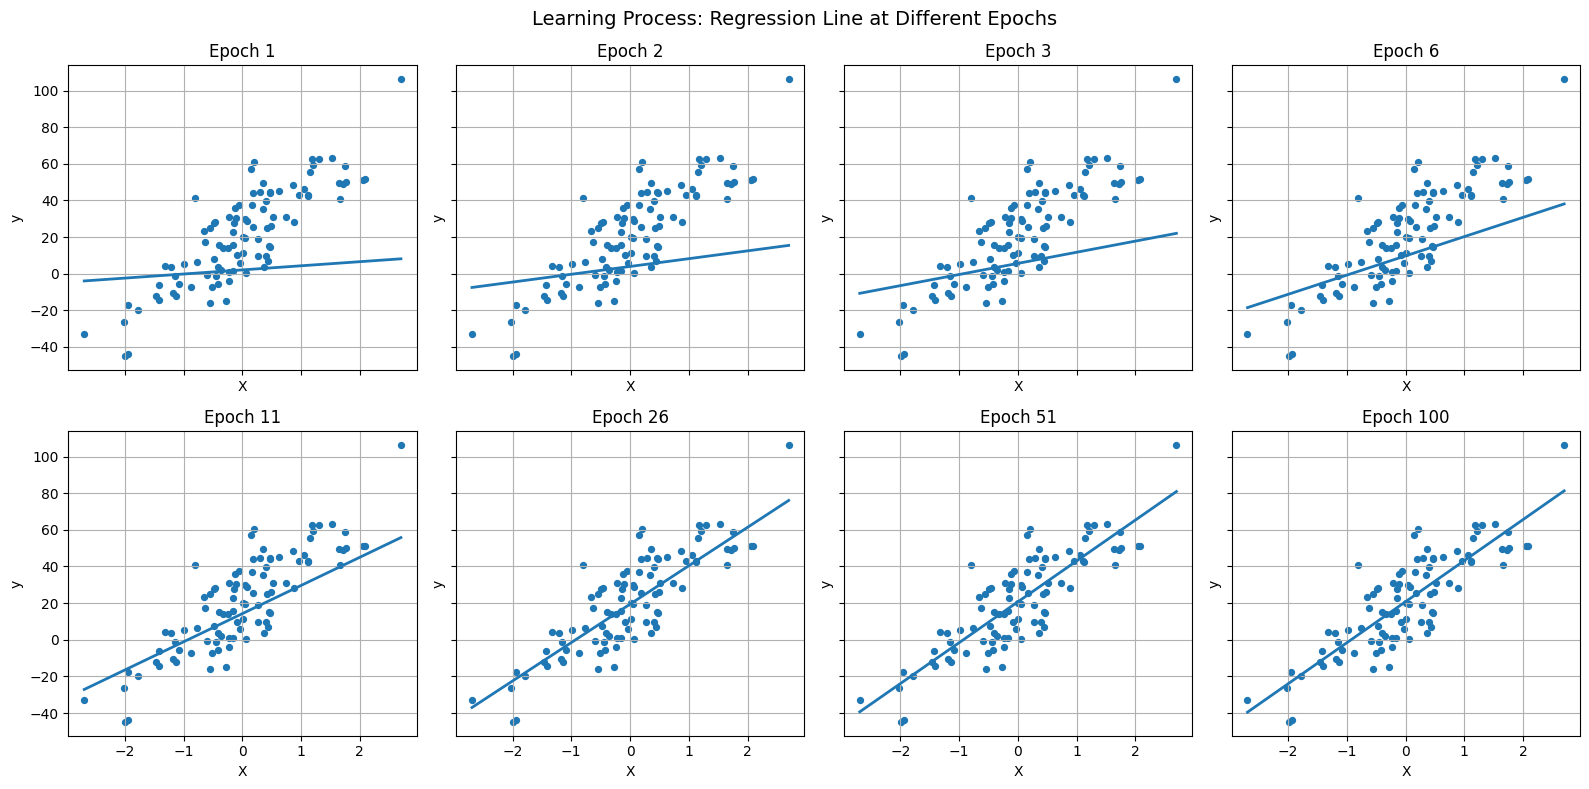

In [13]:
selected_epochs = [0, 1, 2, 5, 10, 25, 50, 99]
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)

for ax, epoch in zip(axes.ravel(), selected_epochs):
    ax.scatter(X_train_scaled[:, 0], y_train, s=18)
    w = gd_w_history[epoch]
    b = gd_b_history[epoch]
    ax.plot(x_line, w * x_line + b, linewidth=2)
    ax.set_title(f'Epoch {epoch + 1}')
    ax.set_xlabel('X')
    ax.set_ylabel('y')

plt.suptitle('Learning Process: Regression Line at Different Epochs', fontsize=14)
plt.tight_layout()
plt.show()


## 10. Evaluate the final models

We calculate MSE and R² on the held-out test set. These metrics are computed manually so the notebook remains focused on understanding the algorithm.

In [14]:
def predict(X, w, b):
    return w * X[:, 0] + b

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r2_score_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

gd_test_pred = predict(X_test_scaled, w_gd, b_gd)
sgd_test_pred = predict(X_test_scaled, w_sgd, b_sgd)

print('Batch Gradient Descent')
print('MSE:', mse(y_test, gd_test_pred))
print('R² :', r2_score_manual(y_test, gd_test_pred))

print('\nStochastic Gradient Descent')
print('MSE:', mse(y_test, sgd_test_pred))
print('R² :', r2_score_manual(y_test, sgd_test_pred))


Batch Gradient Descent
MSE: 189.5187686791469
R² : 0.6901362720648796

Stochastic Gradient Descent
MSE: 200.75185029176836
R² : 0.6717701515537275
